<a href="https://colab.research.google.com/github/Kaiking28/ECON3916-Statistical-Machine-Learning/blob/main/class14/lab14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- NAIVE BASELINE OLS MODEL ---
                             OLS Regression Results                            
Dep. Variable:     AI_Software_Revenue   R-squared:                       0.972
Model:                             OLS   Adj. R-squared:                  0.972
Method:                  Least Squares   F-statistic:                     2831.
Date:                 Tue, 07 Apr 2026   Prob (F-statistic):          2.35e-190
Time:                         20:06:08   Log-Likelihood:                -1409.7
No. Observations:                  250   AIC:                             2827.
Df Residuals:                      246   BIC:                             2841.
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

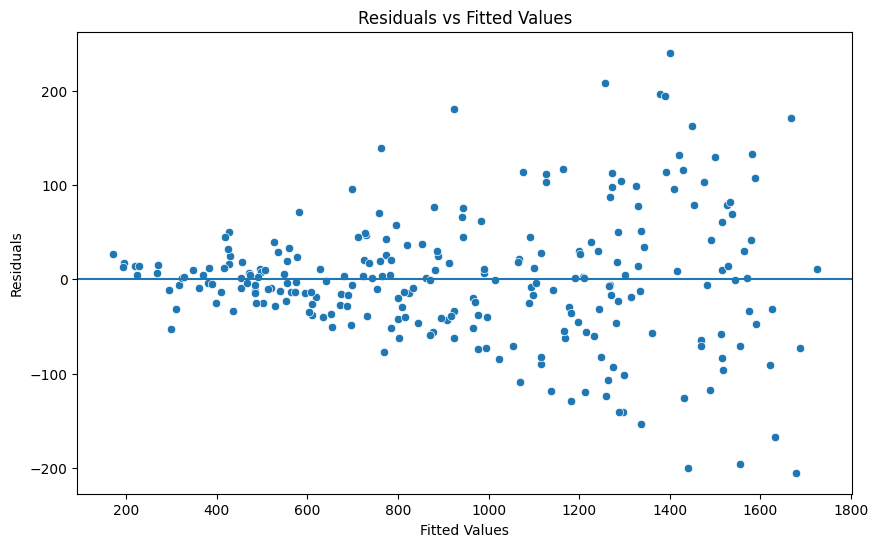


--- WHITE TEST RESULTS ---
{'LM Statistic': '57.28', 'LM-Test p-value': '0.00', 'F-Statistic': '7.93', 'F-Test p-value': '0.00'}

--- VARIANCE INFLATION FACTORS ---
Feature 1: VIF = 18.19
Feature 2: VIF = 18.18
Feature 3: VIF = 1.00

--- ROBUST OLS MODEL (HC3) ---
                             OLS Regression Results                            
Dep. Variable:     AI_Software_Revenue   R-squared:                       0.972
Model:                             OLS   Adj. R-squared:                  0.972
Method:                  Least Squares   F-statistic:                     2375.
Date:                 Tue, 07 Apr 2026   Prob (F-statistic):          2.91e-181
Time:                         20:06:09   Log-Likelihood:                -1409.7
No. Observations:                  250   AIC:                             2827.
Df Residuals:                      246   BIC:                             2841.
Df Model:                            3                                         
Covariance Typ

In [2]:
# Step 1: Imports and Data Load
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

url = '/content/Nvidia_AI_Capex_Diagnostics_2026.csv'
df = pd.read_csv(url)

# Baseline model
formula = 'AI_Software_Revenue ~ Hardware_Capex + Data_Center_Power_MW + Cloud_GPU_Deployments'
baseline_model = smf.ols(formula, data=df).fit()

print("--- NAIVE BASELINE OLS MODEL ---")
print(baseline_model.summary())


# Step 2
fitted_vals = baseline_model.fittedvalues
residuals = baseline_model.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(0)
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()


# Step 3
exog_matrix = baseline_model.model.exog
white_test_results = het_white(baseline_model.resid, exog_matrix)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']

print("\n--- WHITE TEST RESULTS ---")
print(dict(zip(labels, [f"{x:.2f}" for x in white_test_results])))


# Step 4
print("\n--- VARIANCE INFLATION FACTORS ---")

for i in range(1, exog_matrix.shape[1]):
    vif = variance_inflation_factor(exog_matrix, i)
    print(f"Feature {i}: VIF = {vif:.2f}")


# Step 5
robust_model = smf.ols(formula, data=df).fit(cov_type='HC3')

print("\n--- ROBUST OLS MODEL (HC3) ---")
print(robust_model.summary())